<a href="https://colab.research.google.com/github/bekadiscoteka/tb-transformer/blob/main/New_Models_Extension.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🫁 TB Classification — Model Extension: ConvNeXt-Base & MaxViT-Tiny

This notebook extends the existing three-model benchmark (ViT-B/16, DeiT-B, Swin-T)
with two additional architectures:

| Model | timm ID | Family | Why added |
|---|---|---|---|
| **ConvNeXt-Base** | `convnext_base` | Pure CNN (modernised) | CNN baseline — closes the transformer-vs-CNN gap explicitly stated as a limitation in §VI |
| **MaxViT-Tiny** | `maxvit_tiny_tf_224` | Hybrid (Conv + Global + Local Attention) | 4th transformer family — multi-axis attention combines local window + global grid attention in a single block |

**Why these two specifically:**
- ConvNeXt was built to match Swin Transformer using only convolutions — so a performance gap directly isolates what self-attention contributes, which is the core argument of §VI Discussion
- MaxViT combines depthwise conv, local window attention, AND global grid attention in each block — architecturally distinct from all three existing models, and has strong medical imaging precedent
- Both load identically via `timm` — zero pipeline changes
- Both accept 224×224 input — matches existing protocol exactly

**Identical protocol** to the three existing models:
- Same TBX11K dataset, same 70/15/15 stratified split (seed=42)
- Same AdamW lr=1e-4, wd=1e-4, cosine annealing, 15 epochs max
- Same weighted CrossEntropyLoss + label smoothing=0.05
- Same AMP + early stopping on val PR-AUC (patience=5)
- Same threshold optimisation via val F1
- **All plots match the paper's visual analysis structure exactly**

> ⚡ Set runtime to **GPU → T4**: *Runtime > Change runtime type*

## 1. Install & Import

In [1]:
!pip -q install -U timm kagglehub scikit-learn pandas matplotlib seaborn tqdm umap-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 4.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3

In [2]:
import os, gc, json, time, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.auto import tqdm
from PIL import Image, ImageFile

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    matthews_corrcoef, balanced_accuracy_score,
    precision_recall_curve, roc_curve, brier_score_loss
)
from sklearn.calibration import calibration_curve

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
import kagglehub

warnings.filterwarnings('ignore')
ImageFile.LOAD_TRUNCATED_IMAGES = True

# ── Reproducibility (identical to existing notebook) ─────────
SEED = 42
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
seed_everything(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


## 2. Config — Identical Protocol to Existing Models

In [3]:
CFG = {
    # ── Dataset ───────────────────────────────────────────────
    'dataset_slug':          'usmanshams/tbx-11',
    # ── Image / loader ────────────────────────────────────────
    'img_size':              224,
    'batch_size':            16,
    'num_workers':           0,     # Colab requirement
    # ── Splits (must match original notebook exactly) ─────────
    'test_size':             0.15,
    'val_size_from_train':   0.1765,
    # ── Training ──────────────────────────────────────────────
    'epochs':                15,
    'lr':                    1e-4,
    'weight_decay':          1e-4,
    'label_smoothing':       0.05,
    'use_amp':               True,
    'patience':              5,
    # ── NEW models ────────────────────────────────────────────
    'new_models': [
        'convnext_base',              # CNN baseline (modernised)
        'maxvit_tiny_tf_224',         # Hybrid conv + multi-axis attention
    ],
    # ── Results already in the paper (for joint comparison plots)
    'existing_results': {
        'vit_base_patch16_224':             {'roc_auc':0.994,'pr_auc':0.954,'recall_sensitivity':0.908,'specificity':0.992,'precision':0.924,'f1':0.916,'balanced_accuracy':0.950,'mcc':0.910,'tp':109,'fp':9,'fn':11,'tn':1131},
        'deit_base_patch16_224':            {'roc_auc':0.999,'pr_auc':0.992,'recall_sensitivity':0.917,'specificity':0.997,'precision':0.974,'f1':0.944,'balanced_accuracy':0.957,'mcc':0.942,'tp':110,'fp':3,'fn':10,'tn':1137},
        'swin_tiny_patch4_window7_224':     {'roc_auc':1.000,'pr_auc':0.997,'recall_sensitivity':0.967,'specificity':0.995,'precision':0.951,'f1':0.959,'balanced_accuracy':0.981,'mcc':0.952,'tp':116,'fp':6,'fn':4,'tn':1134},
    },
    'output_dir': '/content/tbx11k_extension'
}
os.makedirs(CFG['output_dir'], exist_ok=True)
print('Config ready. New models:', CFG['new_models'])

Config ready. New models: ['convnext_base', 'maxvit_tiny_tf_224']


## 3. Dataset — Identical Loading & Split as Original Notebook

In [4]:
dataset_root = kagglehub.dataset_download(CFG['dataset_slug'])
dataset_root = Path(dataset_root)
print('Dataset root:', dataset_root)

def find_dir_by_name(root, name):
    matches = [p for p in root.rglob('*') if p.is_dir() and p.name.lower() == name.lower()]
    if not matches:
        raise FileNotFoundError(f"'{name}' not found in {root}")
    return matches[0]

imgs_dir = find_dir_by_name(dataset_root, 'imgs')
print('imgs_dir:', imgs_dir)

IMG_EXTS = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}

def infer_label(raw_path):
    top = raw_path.strip().replace('\\', '/').split('/')[0].lower()
    if top == 'tb':                                              return 1
    if top in {'health','healthy','normal','sick','sick_non_tb','non_tb','nontb'}: return 0
    return None

rows = []
for fp in imgs_dir.rglob('*'):
    if fp.is_file() and fp.suffix.lower() in IMG_EXTS:
        rel = fp.relative_to(imgs_dir).as_posix()
        rows.append({'image_path': str(fp), 'label': infer_label(rel)})

full_df = pd.DataFrame(rows)
df = full_df.dropna(subset=['label']).copy()
df['label'] = df['label'].astype(int)
df = df[df['image_path'].apply(os.path.exists)].reset_index(drop=True)
print(f'Labeled images: {len(df)}')
print(df['label'].value_counts())

100%|██████████| 3.08G/3.08G [03:39<00:00, 15.1MB/s]

Extracting files...


Dataset root: /root/.cache/kagglehub/datasets/usmanshams/tbx-11/versions/1
imgs_dir: /root/.cache/kagglehub/datasets/usmanshams/tbx-11/versions/1/TBX11K/imgs
Labeled images: 8400
label
0    7600
1     800
Name: count, dtype: int64


In [5]:
# ── Exact same split as original notebook ─────────────────────
train_val_df, test_df = train_test_split(
    df, test_size=CFG['test_size'], stratify=df['label'], random_state=SEED)
train_df, val_df = train_test_split(
    train_val_df, test_size=CFG['val_size_from_train'],
    stratify=train_val_df['label'], random_state=SEED)

print(f'TRAIN: {len(train_df)}  VAL: {len(val_df)}  TEST: {len(test_df)}')

# Class weights
cc = train_df['label'].value_counts().sort_index()
class_weights = torch.tensor([1.0, cc[0]/cc[1]], dtype=torch.float32).to(DEVICE)
print('Class weights:', class_weights)

TRAIN: 5879  VAL: 1261  TEST: 1260
Class weights: tensor([1.0000, 9.4982], device='cuda:0')


In [6]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(8),
    transforms.ColorJitter(brightness=0.05, contrast=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tf = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class TBXDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, int(row['label'])

train_loader = DataLoader(TBXDataset(train_df, train_tf), batch_size=CFG['batch_size'],
                          shuffle=True,  num_workers=CFG['num_workers'],
                          pin_memory=torch.cuda.is_available())
val_loader   = DataLoader(TBXDataset(val_df,   eval_tf),  batch_size=CFG['batch_size'],
                          shuffle=False, num_workers=CFG['num_workers'],
                          pin_memory=torch.cuda.is_available())
test_loader  = DataLoader(TBXDataset(test_df,  eval_tf),  batch_size=CFG['batch_size'],
                          shuffle=False, num_workers=CFG['num_workers'],
                          pin_memory=torch.cuda.is_available())
print('DataLoaders ready.')

DataLoaders ready.


## 4. Model Architecture Notes

### ConvNeXt-Base
ConvNeXt (Liu et al., 2022) is a pure CNN redesigned to match Swin Transformer's
performance by adopting its training recipe and key design choices: large 7×7
depthwise convolution kernels, inverted bottleneck blocks, LayerNorm instead of
BatchNorm, and GELU activations. It has **~89M parameters** and is the strongest
modern CNN baseline. Because ConvNeXt mimics Swin's design philosophy without
self-attention, any performance gap between them directly isolates what the
self-attention mechanism itself contributes to TB classification — exactly the
argument made in §VI of the paper.

### MaxViT-Tiny
MaxViT (Tu et al., NeurIPS 2022) introduces Multi-Axis Self-Attention (Max-SA),
combining depthwise convolution, **local window attention** (like Swin), and
**global grid attention** (sparse global coverage) in every block. This gives it
local-to-global reasoning in a single forward pass without the quadratic cost
of full global attention. MaxViT-Tiny has **~31M parameters** — comparable to
Swin-T (~28M) — making it a parameter-fair 4th transformer family representative.
It has shown strong results on medical imaging benchmarks.

In [7]:
def build_model(model_name, num_classes=2):
    model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)
    return model.to(DEVICE)

# Quick param count check
for name in CFG['new_models']:
    m = build_model(name)
    params = sum(p.numel() for p in m.parameters()) / 1e6
    print(f'{name:45s}  {params:6.1f}M params')
    del m
    gc.collect()
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

model.safetensors:   0%|          | 0.00/354M [00:00<?, ?B/s]

convnext_base                                    87.6M params


model.safetensors:   0%|          | 0.00/124M [00:00<?, ?B/s]

maxvit_tiny_tf_224                               30.4M params


## 5. Core Training & Metric Functions — Identical to Original

In [8]:
def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'accuracy':           accuracy_score(y_true, y_pred),
        'balanced_accuracy':  balanced_accuracy_score(y_true, y_pred),
        'precision':          precision_score(y_true, y_pred, zero_division=0),
        'recall_sensitivity': recall_score(y_true, y_pred, zero_division=0),
        'specificity':        tn/(tn+fp) if (tn+fp)>0 else 0.0,
        'f1':                 f1_score(y_true, y_pred, zero_division=0),
        'mcc':                matthews_corrcoef(y_true, y_pred),
        'roc_auc':            roc_auc_score(y_true, y_prob),
        'pr_auc':             average_precision_score(y_true, y_prob),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
    }

def find_best_threshold_by_f1(y_true, y_prob):
    _, _, thresholds = precision_recall_curve(y_true, y_prob)
    best_t, best_f1 = 0.5, -1.0
    for t in thresholds:
        y_pred = (np.array(y_prob) >= t).astype(int)
        f = f1_score(y_true, y_pred, zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, float(t)
    return best_t, best_f1

def run_one_epoch(model, loader, criterion, optimizer=None, scaler=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, all_labels, all_probs = 0.0, [], []
    for images, labels in tqdm(loader, leave=False):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        if is_train: optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=CFG['use_amp'] and torch.cuda.is_available()):
            logits = model(images)
            loss   = criterion(logits, labels)
            probs  = torch.softmax(logits, dim=1)[:, 1]
        if is_train:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        total_loss += loss.item() * images.size(0)
        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_probs.extend(probs.detach().cpu().numpy().tolist())
    return total_loss / len(loader.dataset), np.array(all_labels), np.array(all_probs)

## 6. Plotting Functions — Matching Paper's Visual Analysis Structure

In [9]:
MODEL_LABELS = {
    'convnext_base':             'ConvNeXt-B',
    'maxvit_tiny_tf_224':        'MaxViT-T',
    'vit_base_patch16_224':      'ViT-B/16',
    'deit_base_patch16_224':     'DeiT-B',
    'swin_tiny_patch4_window7_224': 'Swin-T',
}
MODEL_COLORS = {
    'convnext_base':             '#E07B54',   # coral — CNN family
    'maxvit_tiny_tf_224':        '#7B68EE',   # medium slate blue — hybrid
    'vit_base_patch16_224':      '#4C9BE8',   # blue
    'deit_base_patch16_224':     '#2ECC9A',   # teal
    'swin_tiny_patch4_window7_224': '#F5A623', # amber
}

# ── Plot 1: Training curves (loss / ROC-AUC / PR-AUC) ────────
def plot_training_curves(hist_df, model_name):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    color = MODEL_COLORS.get(model_name, '#333')
    for ax, tr_key, vl_key, title in zip(
            axes,
            ['train_loss', 'train_roc_auc', 'train_pr_auc'],
            ['val_loss',   'val_roc_auc',   'val_pr_auc'],
            ['Loss', 'ROC-AUC', 'PR-AUC']):
        ax.plot(hist_df['epoch'], hist_df[tr_key], label='Train', color=color, linewidth=2)
        ax.plot(hist_df['epoch'], hist_df[vl_key], label='Val',   color=color,
                linewidth=2, linestyle='--')
        ax.set_title(title, fontsize=12)
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(alpha=0.3)
    plt.suptitle(f'Training Curves — {MODEL_LABELS.get(model_name, model_name)}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{CFG['output_dir']}/curves_{model_name}.png", dpi=150, bbox_inches='tight')
    plt.show()

# ── Plot 2: CM + ROC + PR (matches paper Figs 11 style) ──────
def plot_confusion_and_curves(y_true, y_prob, threshold, model_name):
    y_pred = (np.array(y_prob) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    color = MODEL_COLORS.get(model_name, '#4C9BE8')

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Non-TB','TB'], yticklabels=['Non-TB','TB'])
    axes[0].set_title('Confusion Matrix'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    axes[1].plot(fpr, tpr, color=color, linewidth=2,
                 label=f'AUC = {roc_auc_score(y_true, y_prob):.3f}')
    axes[1].plot([0,1],[0,1],'k--', linewidth=1)
    axes[1].set_title('ROC Curve'); axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    axes[2].plot(rec, prec, color=color, linewidth=2,
                 label=f'PR-AUC = {average_precision_score(y_true, y_prob):.3f}')
    axes[2].set_title('Precision-Recall Curve'); axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
    axes[2].legend(); axes[2].grid(alpha=0.3)

    plt.suptitle(f'Evaluation — {MODEL_LABELS.get(model_name, model_name)}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{CFG['output_dir']}/eval_{model_name}.png", dpi=150, bbox_inches='tight')
    plt.show()

# ── Plot 3: Calibration + Confidence (matches paper Fig. 10) ─
def plot_calibration_and_confidence(y_true, y_prob, model_name):
    color = MODEL_COLORS.get(model_name, '#4C9BE8')
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Reliability diagram
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy='uniform')
    axes[0].plot(prob_pred, prob_true, 's-', color=color, linewidth=2, label=MODEL_LABELS.get(model_name, model_name))
    axes[0].plot([0,1],[0,1],'k--', linewidth=1, label='Perfect calibration')
    brier = brier_score_loss(y_true, y_prob)
    axes[0].set_title(f'Reliability Diagram\n(Brier score = {brier:.4f})', fontsize=11)
    axes[0].set_xlabel('Mean predicted probability'); axes[0].set_ylabel('Fraction of positives')
    axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

    # Confidence distributions
    y_true_arr = np.array(y_true)
    correct_mask = (y_true_arr == (np.array(y_prob) >= 0.5).astype(int))
    axes[1].hist(np.array(y_prob)[correct_mask],  bins=30, alpha=0.6, color='steelblue', label='Correct')
    axes[1].hist(np.array(y_prob)[~correct_mask], bins=30, alpha=0.6, color='crimson',   label='Incorrect')
    axes[1].set_title('Confidence Distribution', fontsize=11)
    axes[1].set_xlabel('Predicted TB probability'); axes[1].set_ylabel('Count')
    axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

    plt.suptitle(f'Calibration & Confidence — {MODEL_LABELS.get(model_name, model_name)}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{CFG['output_dir']}/calibration_{model_name}.png", dpi=150, bbox_inches='tight')
    plt.show()

print('Plotting functions ready.')

Plotting functions ready.


## 7. Train & Evaluate Both New Models


MODEL: convnext_base


  0%|          | 0/368 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

  Epoch 01/15 | train_loss=0.5908 | val_loss=0.4942 | val_roc_auc=0.9843 | val_pr_auc=0.9092 | val_f1=0.8319 | 203.6s
  ✓ Saved checkpoint (val PR-AUC=0.9092)


  0%|          | 0/368 [00:00<?, ?it/s]

...

  0%|          | 0/79 [00:00<?, ?it/s]

  Epoch 15/15 | train_loss=0.3525 | val_loss=0.3713 | val_roc_auc=0.9999 | val_pr_auc=0.9991 | val_f1=0.9832 | 163.4s
  No improvement (1/5)


  0%|          | 0/79 [00:00<?, ?it/s]

  Best threshold=0.3540  val F1=0.9876


  0%|          | 0/79 [00:00<?, ?it/s]

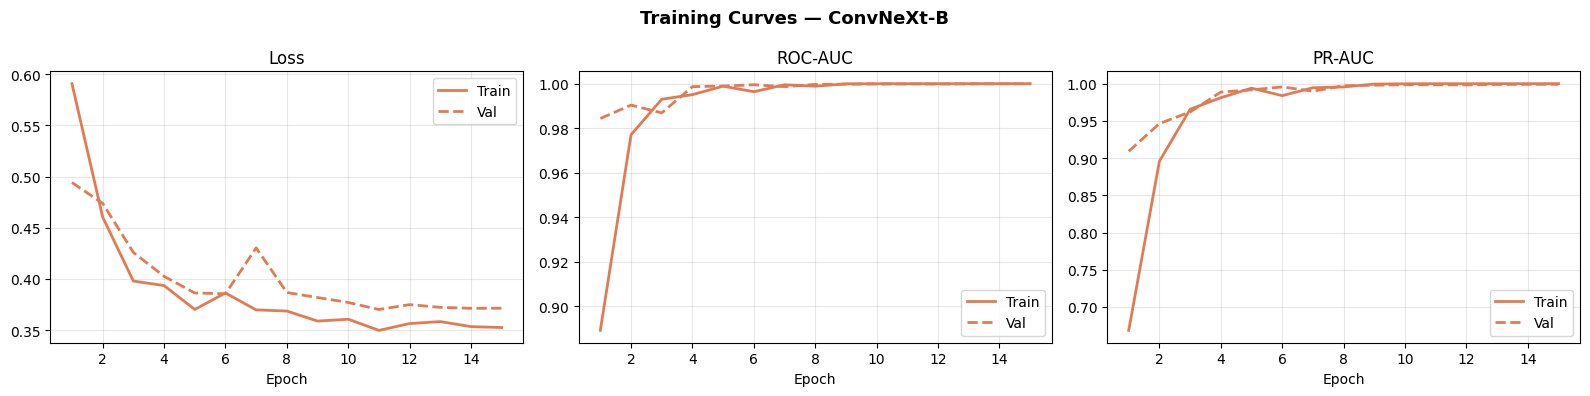

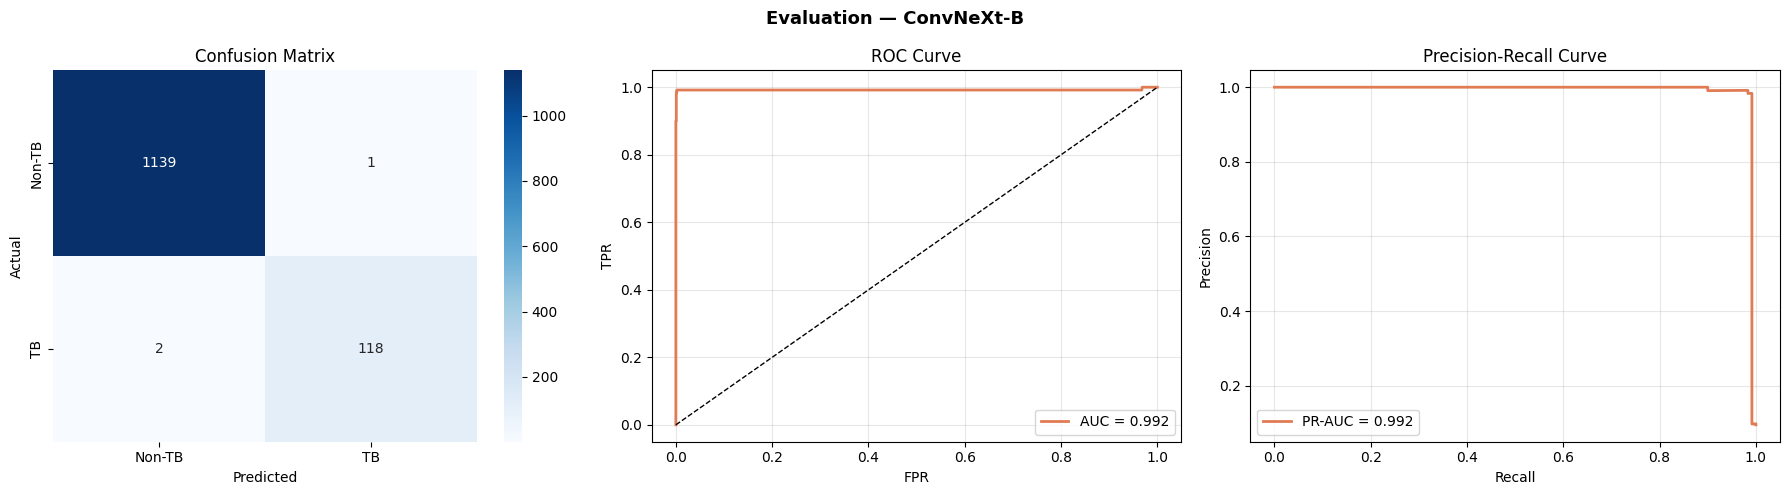

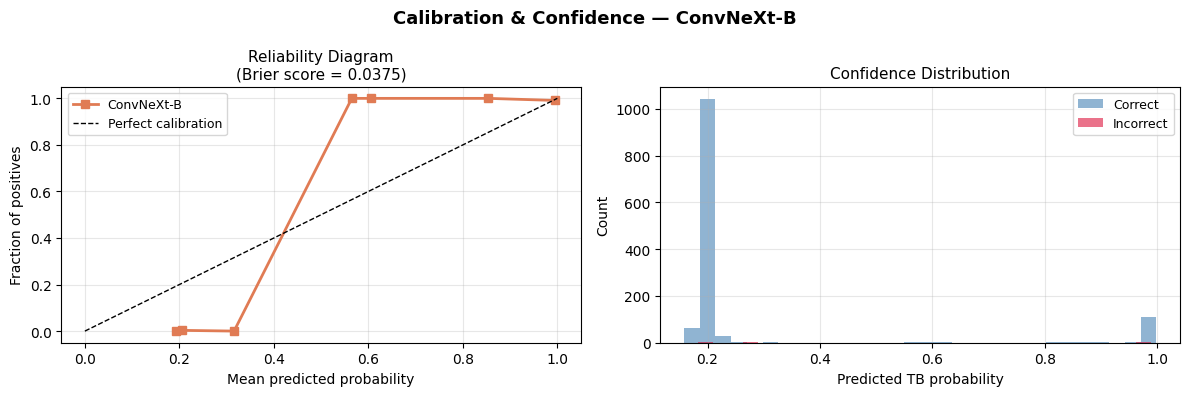


MODEL: maxvit_tiny_tf_224


  0%|          | 0/368 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

  Epoch 01/15 | train_loss=0.5280 | val_loss=0.4773 | val_roc_auc=0.9893 | val_pr_auc=0.9388 | val_f1=0.8707 | 190.3s
  ✓ Saved checkpoint (val PR-AUC=0.9388)


  0%|          | 0/368 [00:00<?, ?it/s]

...

  0%|          | 0/79 [00:00<?, ?it/s]

  Epoch 09/15 | train_loss=0.3616 | val_loss=0.3904 | val_roc_auc=0.9975 | val_pr_auc=0.9787 | val_f1=0.9105 | 164.8s
  No improvement (5/5)
  Early stopping triggered.


  0%|          | 0/79 [00:00<?, ?it/s]

  Best threshold=0.7816  val F1=0.9752


  0%|          | 0/79 [00:00<?, ?it/s]

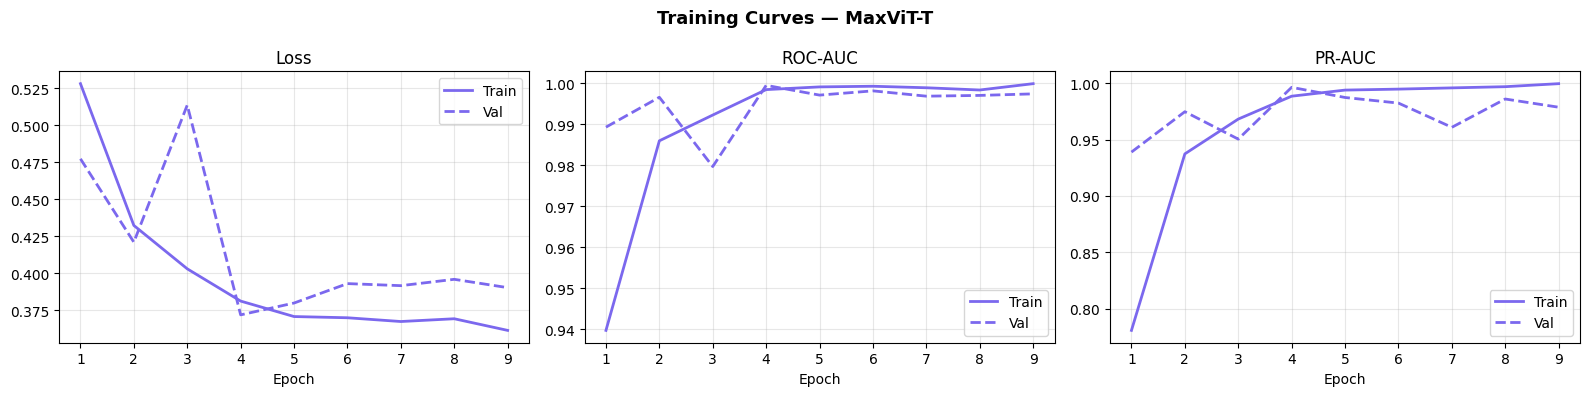

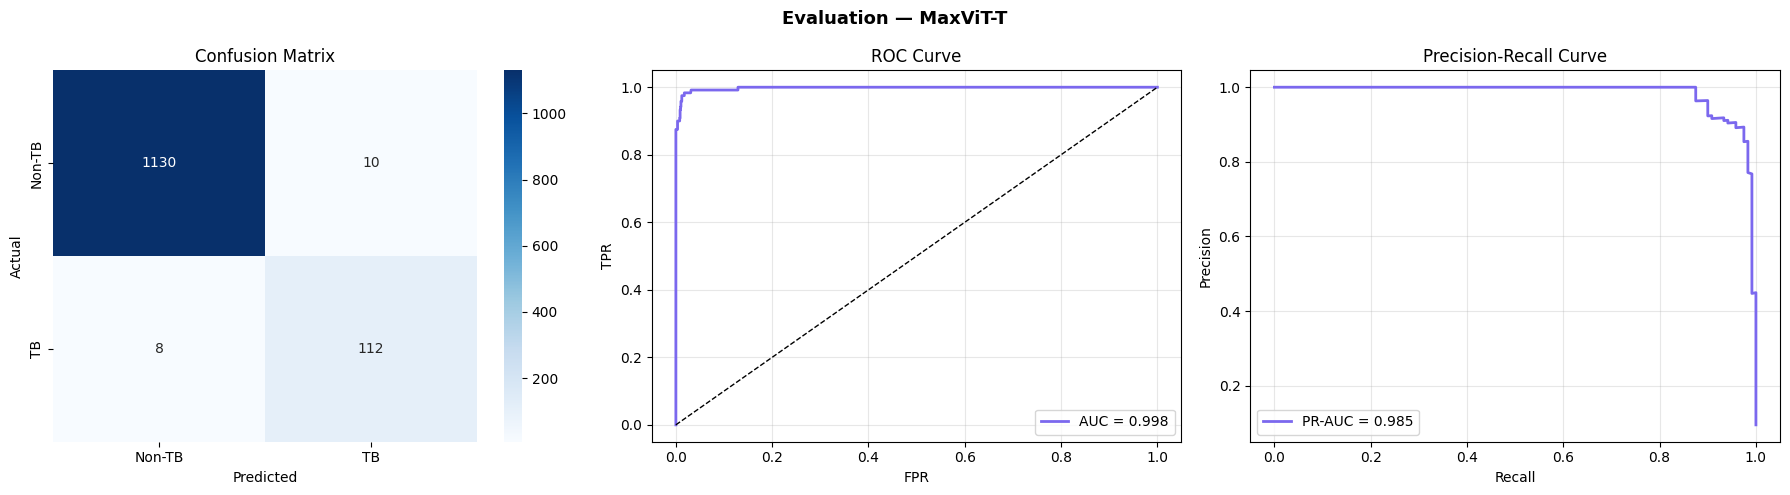

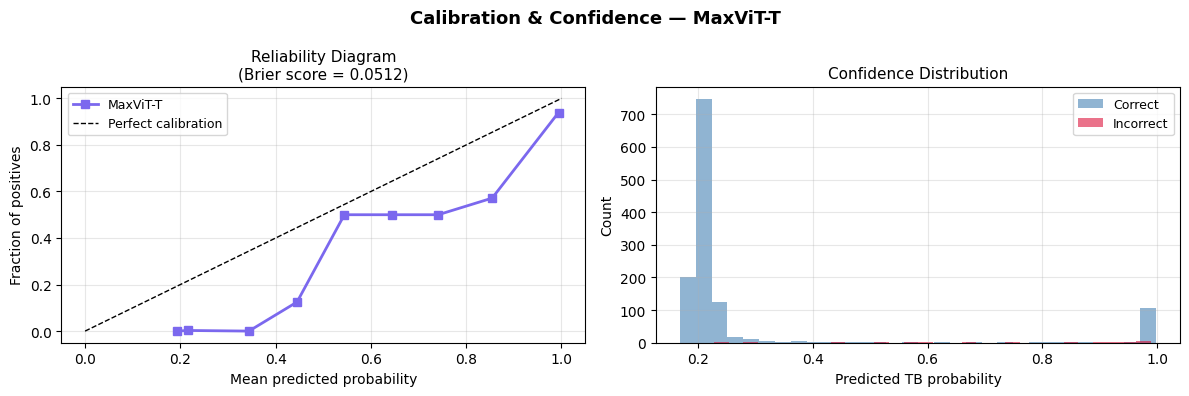


New model results:
        model_name  roc_auc   pr_auc  recall_sensitivity  specificity       f1      mcc
     convnext_base 0.991846 0.991618            0.983333     0.999123 0.987448 0.986143
maxvit_tiny_tf_224 0.997686 0.984558            0.933333     0.991228 0.925620 0.917757


In [10]:
def train_and_evaluate(model_name):
    print(f'\n{"="*80}\nMODEL: {model_name}\n{"="*80}')

    model     = build_model(model_name)
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=CFG['label_smoothing'])
    optimizer = optim.AdamW(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG['epochs'])
    scaler    = torch.cuda.amp.GradScaler(enabled=CFG['use_amp'] and torch.cuda.is_available())

    best_path      = Path(CFG['output_dir']) / f"best_{model_name}.pth"
    best_val_prauc = -np.inf
    patience_ctr   = 0
    history        = []

    for epoch in range(1, CFG['epochs'] + 1):
        t0 = time.time()
        tr_loss, tr_y, tr_p = run_one_epoch(model, train_loader, criterion, optimizer, scaler)
        vl_loss, vl_y, vl_p = run_one_epoch(model, val_loader,   criterion)
        scheduler.step()

        tr_m = compute_binary_metrics(tr_y, tr_p)
        vl_m = compute_binary_metrics(vl_y, vl_p)

        history.append({
            'epoch': epoch,
            'train_loss': tr_loss, 'val_loss': vl_loss,
            'train_roc_auc': tr_m['roc_auc'], 'val_roc_auc': vl_m['roc_auc'],
            'train_pr_auc':  tr_m['pr_auc'],  'val_pr_auc':  vl_m['pr_auc'],
            'train_f1':      tr_m['f1'],       'val_f1':      vl_m['f1'],
        })

        print(f"  Epoch {epoch:02d}/{CFG['epochs']} | "
              f"train_loss={tr_loss:.4f} | val_loss={vl_loss:.4f} | "
              f"val_roc_auc={vl_m['roc_auc']:.4f} | val_pr_auc={vl_m['pr_auc']:.4f} | "
              f"val_f1={vl_m['f1']:.4f} | {time.time()-t0:.1f}s")

        if vl_m['pr_auc'] > best_val_prauc:
            best_val_prauc = vl_m['pr_auc']
            patience_ctr   = 0
            torch.save({'model_state_dict': model.state_dict(), 'history': history,
                        'best_val_pr_auc': best_val_prauc}, best_path)
            print(f'  ✓ Saved checkpoint (val PR-AUC={best_val_prauc:.4f})')
        else:
            patience_ctr += 1
            print(f'  No improvement ({patience_ctr}/{CFG["patience"]})')
            if patience_ctr >= CFG['patience']:
                print('  Early stopping triggered.')
                break

    # ── Restore best checkpoint ───────────────────────────────
    model.load_state_dict(torch.load(best_path, map_location=DEVICE)['model_state_dict'])

    # ── Optimal threshold from validation ─────────────────────
    _, vl_y, vl_p = run_one_epoch(model, val_loader, criterion)
    best_t, best_f1_val = find_best_threshold_by_f1(vl_y, vl_p)
    print(f'  Best threshold={best_t:.4f}  val F1={best_f1_val:.4f}')

    # ── Test evaluation ───────────────────────────────────────
    te_loss, te_y, te_p = run_one_epoch(model, test_loader, criterion)
    test_metrics = compute_binary_metrics(te_y, te_p, threshold=best_t)
    test_metrics.update({'model_name': model_name, 'test_loss': te_loss,
                         'best_threshold': best_t})

    # ── Save artefacts ────────────────────────────────────────
    hist_df = pd.DataFrame(history)
    hist_df.to_csv(f"{CFG['output_dir']}/{model_name}_history.csv", index=False)
    with open(f"{CFG['output_dir']}/{model_name}_metrics.json", 'w') as f:
        json.dump(test_metrics, f, indent=2)

    # ── Plots ─────────────────────────────────────────────────
    plot_training_curves(hist_df, model_name)
    plot_confusion_and_curves(te_y, te_p, best_t, model_name)
    plot_calibration_and_confidence(te_y, te_p, model_name)

    # ── Store probs/labels for later joint plots ──────────────
    np.save(f"{CFG['output_dir']}/{model_name}_test_probs.npy",  te_p)
    np.save(f"{CFG['output_dir']}/{model_name}_test_labels.npy", te_y)

    del model; gc.collect()
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

    return test_metrics

# ── Run both new models ───────────────────────────────────────
new_results = []
for mname in CFG['new_models']:
    res = train_and_evaluate(mname)
    new_results.append(res)

new_df = pd.DataFrame(new_results)
new_df.to_csv(f"{CFG['output_dir']}/new_models_results.csv", index=False)
print('\nNew model results:')
print(new_df[['model_name','roc_auc','pr_auc','recall_sensitivity','specificity','f1','mcc']].to_string(index=False))

## 8. Joint Comparison Plots — All 5 Models Together

In [11]:
# ── Build combined results dataframe ─────────────────────────
existing_rows = []
for mname, mdict in CFG['existing_results'].items():
    row = dict(mdict)
    row['model_name'] = mname
    existing_rows.append(row)

all_df = pd.concat([pd.DataFrame(existing_rows), new_df], ignore_index=True)
all_df['label'] = all_df['model_name'].map(MODEL_LABELS)

# Fixed display order: 3 existing (ViT, DeiT, Swin) then 2 new
ORDER = [
    'vit_base_patch16_224',
    'deit_base_patch16_224',
    'swin_tiny_patch4_window7_224',
    'convnext_base',
    'maxvit_tiny_tf_224',
]
all_df = all_df.set_index('model_name').loc[ORDER].reset_index()
print(all_df[['model_name','roc_auc','pr_auc','recall_sensitivity','specificity','f1','balanced_accuracy','mcc']].to_string(index=False))

                  model_name  roc_auc   pr_auc  recall_sensitivity  specificity       f1  balanced_accuracy      mcc
        vit_base_patch16_224 0.994000 0.954000            0.908000     0.992000 0.916000           0.950000 0.910000
       deit_base_patch16_224 0.999000 0.992000            0.917000     0.997000 0.944000           0.957000 0.942000
swin_tiny_patch4_window7_224 1.000000 0.997000            0.967000     0.995000 0.959000           0.981000 0.952000
               convnext_base 0.991846 0.991618            0.983333     0.999123 0.987448           0.991228 0.986143
          maxvit_tiny_tf_224 0.997686 0.984558            0.933333     0.991228 0.925620           0.962281 0.917757


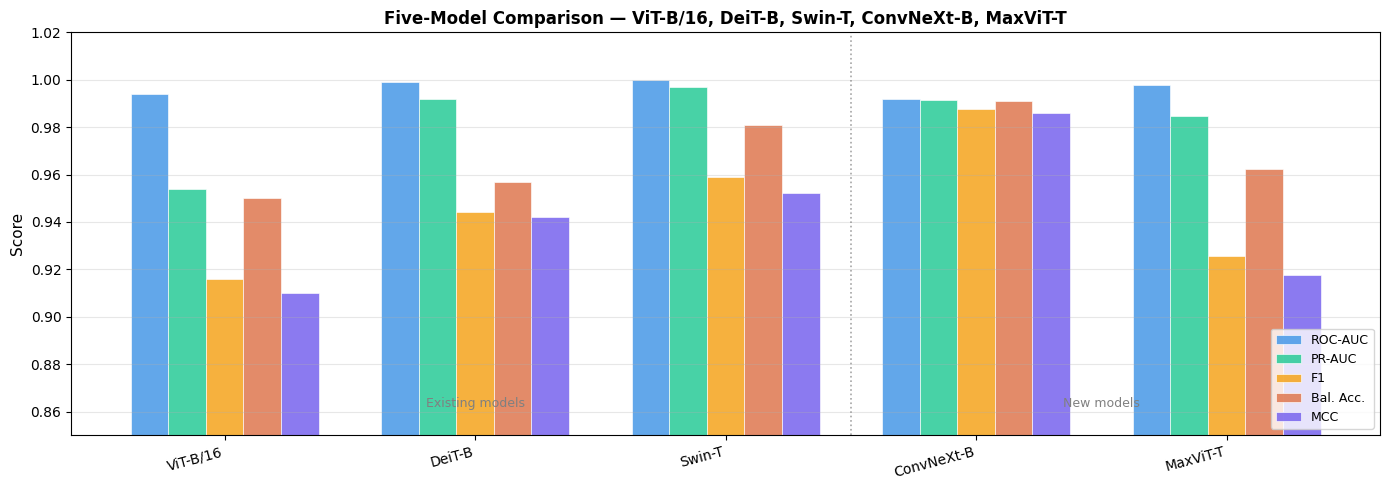

In [12]:
# ── Plot A: Grouped bar chart (matches paper Fig comparison) ──
metrics_to_plot = ['roc_auc', 'pr_auc', 'f1', 'balanced_accuracy', 'mcc']
metric_labels   = ['ROC-AUC', 'PR-AUC', 'F1', 'Bal. Acc.', 'MCC']

x       = np.arange(len(all_df))
n_m     = len(metrics_to_plot)
width   = 0.15
palette = ['#4C9BE8','#2ECC9A','#F5A623','#E07B54','#7B68EE']

fig, ax = plt.subplots(figsize=(14, 5))
for i, (met, lab, col) in enumerate(zip(metrics_to_plot, metric_labels, palette)):
    offset = (i - n_m/2 + 0.5) * width
    bars = ax.bar(x + offset, all_df[met], width, label=lab, color=col,
                  alpha=0.88, edgecolor='white', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(all_df['label'], rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0.85, 1.02)
ax.set_title('Five-Model Comparison — ViT-B/16, DeiT-B, Swin-T, ConvNeXt-B, MaxViT-T',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.axvline(2.5, color='gray', linewidth=1.2, linestyle=':', alpha=0.7)
ax.text(1.0,  0.862, 'Existing models', ha='center', fontsize=9, color='gray')
ax.text(3.5,  0.862, 'New models',      ha='center', fontsize=9, color='gray')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/comparison_all5.png", dpi=150, bbox_inches='tight')
plt.show()

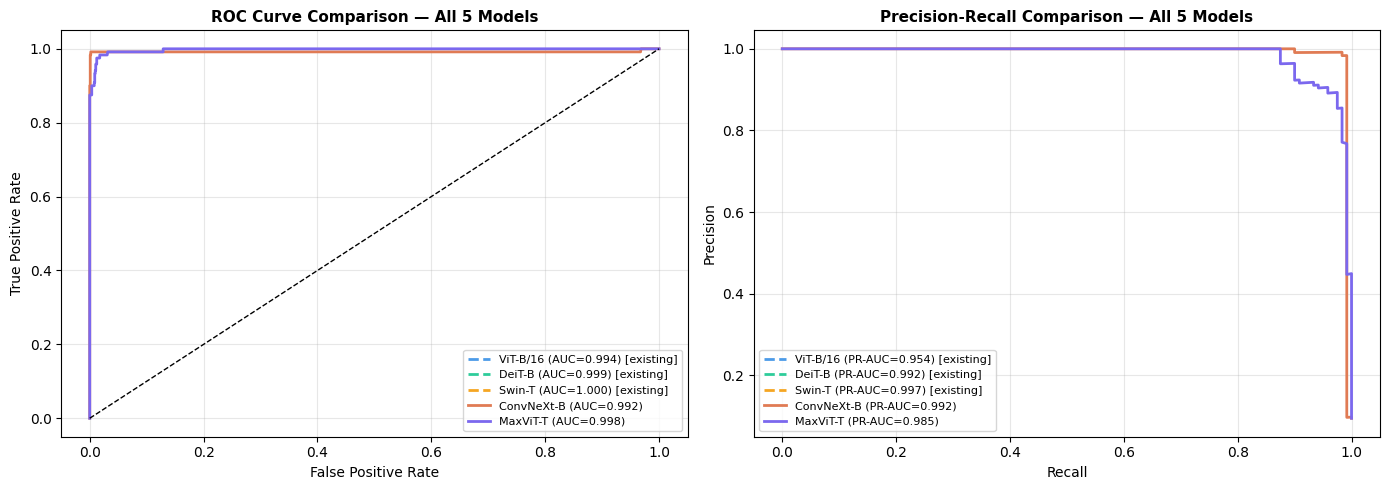

In [13]:
# ── Plot B: Combined ROC curves (all 5 models) ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Load saved probs for new models; use stored AUC for existing
for mname in ORDER:
    label = MODEL_LABELS[mname]
    color = MODEL_COLORS[mname]
    prob_path = Path(CFG['output_dir']) / f'{mname}_test_probs.npy'
    lbl_path  = Path(CFG['output_dir']) / f'{mname}_test_labels.npy'

    if prob_path.exists():
        probs  = np.load(prob_path)
        labels = np.load(lbl_path)
        fpr, tpr, _ = roc_curve(labels, probs)
        prec, rec, _ = precision_recall_curve(labels, probs)
        auc  = roc_auc_score(labels, probs)
        prauc = average_precision_score(labels, probs)
        axes[0].plot(fpr, tpr,  color=color, linewidth=2, label=f'{label} (AUC={auc:.3f})')
        axes[1].plot(rec, prec, color=color, linewidth=2, label=f'{label} (PR-AUC={prauc:.3f})')
    else:
        # Existing models: just annotate stored AUC in legend
        row   = all_df[all_df['model_name'] == mname].iloc[0]
        axes[0].plot([], [], color=color, linewidth=2, linestyle='--',
                     label=f"{label} (AUC={row['roc_auc']:.3f}) [existing]")
        axes[1].plot([], [], color=color, linewidth=2, linestyle='--',
                     label=f"{label} (PR-AUC={row['pr_auc']:.3f}) [existing]")

axes[0].plot([0,1],[0,1],'k--',linewidth=1)
axes[0].set_title('ROC Curve Comparison — All 5 Models', fontsize=11, fontweight='bold')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=8, loc='lower right'); axes[0].grid(alpha=0.3)

axes[1].set_title('Precision-Recall Comparison — All 5 Models', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=8, loc='lower left'); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/roc_pr_all5.png", dpi=150, bbox_inches='tight')
plt.show()

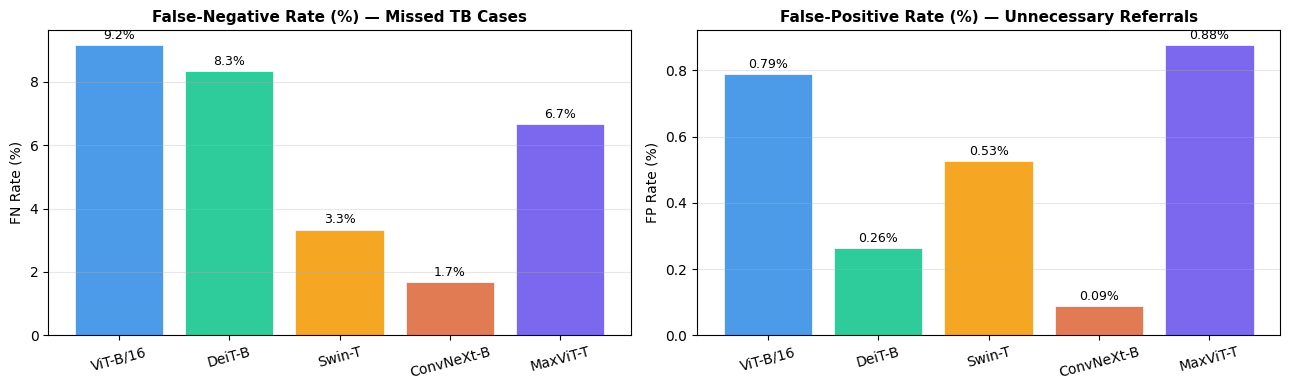

In [14]:
# ── Plot C: Clinical error analysis bar chart ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

fn_rates = all_df['fn'] / (all_df['fn'] + all_df['tp']) * 100
fp_rates = all_df['fp'] / (all_df['fp'] + all_df['tn']) * 100
colors   = [MODEL_COLORS[m] for m in all_df['model_name']]

bars0 = axes[0].bar(all_df['label'], fn_rates, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('False-Negative Rate (%) — Missed TB Cases', fontsize=11, fontweight='bold')
axes[0].set_ylabel('FN Rate (%)')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars0, fn_rates):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

bars1 = axes[1].bar(all_df['label'], fp_rates, color=colors, edgecolor='white', linewidth=0.5)
axes[1].set_title('False-Positive Rate (%) — Unnecessary Referrals', fontsize=11, fontweight='bold')
axes[1].set_ylabel('FP Rate (%)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, fp_rates):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/clinical_errors_all5.png", dpi=150, bbox_inches='tight')
plt.show()

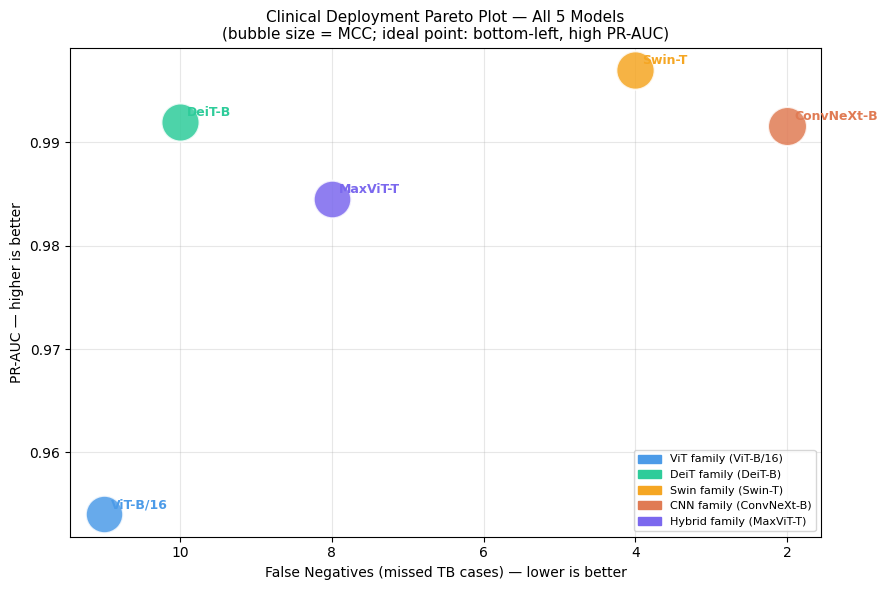

In [15]:
# ── Plot D: Updated Deployment Pareto Plot (matches paper Fig 12) ──
# Axes: x = FN burden (lower is better), y = PR-AUC (higher is better)
# Bubble size encodes MCC; bubble color encodes model family

fig, ax = plt.subplots(figsize=(9, 6))

fn_counts  = all_df['fn'].values
pr_aucs    = all_df['pr_auc'].values
mcc_vals   = all_df['mcc'].values
sizes      = (mcc_vals * 800).clip(100, 1200)

for i, row in all_df.iterrows():
    c = MODEL_COLORS[row['model_name']]
    ax.scatter(row['fn'], row['pr_auc'], s=sizes[i], color=c,
               alpha=0.85, edgecolors='white', linewidth=1.5, zorder=3)
    ax.annotate(MODEL_LABELS[row['model_name']],
                xy=(row['fn'], row['pr_auc']),
                xytext=(5, 4), textcoords='offset points',
                fontsize=9, color=c, fontweight='bold')

ax.set_xlabel('False Negatives (missed TB cases) — lower is better', fontsize=10)
ax.set_ylabel('PR-AUC — higher is better', fontsize=10)
ax.set_title('Clinical Deployment Pareto Plot — All 5 Models\n'
             '(bubble size = MCC; ideal point: bottom-left, high PR-AUC)', fontsize=11)
ax.invert_xaxis()
ax.grid(alpha=0.3)

# Family legend
patches = [
    mpatches.Patch(color='#4C9BE8', label='ViT family (ViT-B/16)'),
    mpatches.Patch(color='#2ECC9A', label='DeiT family (DeiT-B)'),
    mpatches.Patch(color='#F5A623', label='Swin family (Swin-T)'),
    mpatches.Patch(color='#E07B54', label='CNN family (ConvNeXt-B)'),
    mpatches.Patch(color='#7B68EE', label='Hybrid family (MaxViT-T)'),
]
ax.legend(handles=patches, loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/pareto_all5.png", dpi=150, bbox_inches='tight')
plt.show()

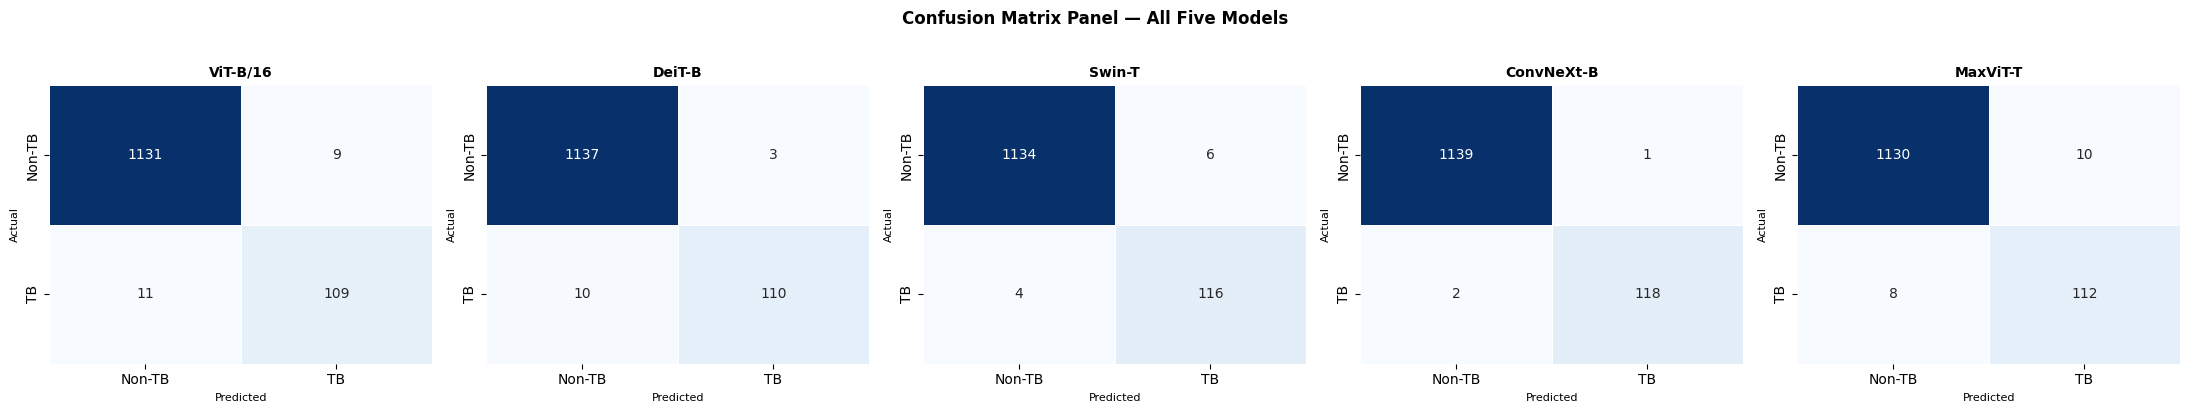

In [16]:
# ── Plot E: Full confusion matrix panel — all 5 (matches paper Fig 11 right) ──
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, (_, row) in zip(axes, all_df.iterrows()):
    cm_data = np.array([[row['tn'], row['fp']], [row['fn'], row['tp']]])
    sns.heatmap(cm_data, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-TB','TB'], yticklabels=['Non-TB','TB'],
                cbar=False, linewidths=0.5)
    ax.set_title(MODEL_LABELS[row['model_name']], fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('Actual', fontsize=8)

plt.suptitle('Confusion Matrix Panel — All Five Models', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/cm_panel_all5.png", dpi=150, bbox_inches='tight')
plt.show()

Extracting convnext_base:   0%|          | 0/79 [00:00<?, ?it/s]

Extracting maxvit_tiny_tf_224:   0%|          | 0/79 [00:00<?, ?it/s]

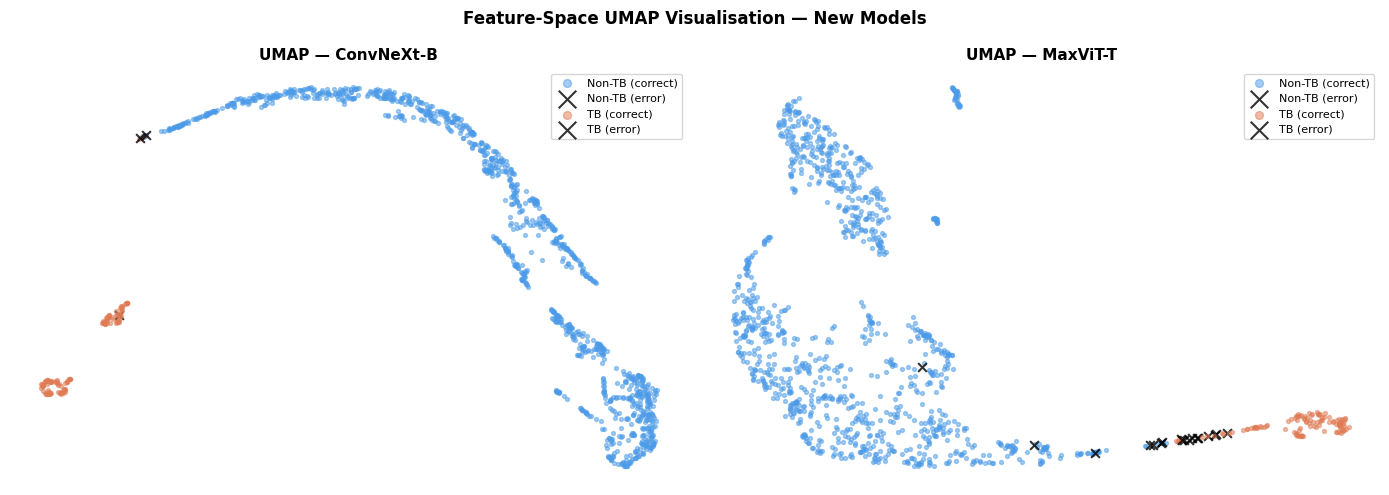

In [17]:
# ── Plot F: UMAP feature-space visualisation for new models ───
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    print('umap-learn not available — skipping UMAP plots')
    UMAP_AVAILABLE = False

if UMAP_AVAILABLE:
    def extract_features(model_name, loader):
        model = build_model(model_name)
        ckpt  = torch.load(f"{CFG['output_dir']}/best_{model_name}.pth", map_location=DEVICE)
        model.load_state_dict(ckpt['model_state_dict'])
        model.eval()

        # Remove classification head — keep penultimate features
        if hasattr(model, 'head'):
            model.head = nn.Identity()
        elif hasattr(model, 'classifier'):
            model.classifier = nn.Identity()
        elif hasattr(model, 'fc'):
            model.fc = nn.Identity()

        feats, labs = [], []
        with torch.no_grad():
            for imgs, labels in tqdm(loader, leave=False, desc=f'Extracting {model_name}'):
                out = model(imgs.to(DEVICE))
                if out.dim() > 2: out = out.mean(dim=[2,3])  # pool if spatial
                feats.append(out.cpu().numpy())
                labs.extend(labels.numpy())
        del model; gc.collect(); torch.cuda.empty_cache() if torch.cuda.is_available() else None
        return np.vstack(feats), np.array(labs)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    label_names = {0: 'Non-TB', 1: 'TB'}
    palette = {0: '#4C9BE8', 1: '#E07B54'}

    for ax, mname in zip(axes, CFG['new_models']):
        feats, labs = extract_features(mname, test_loader)

        reducer   = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=SEED)
        embedding = reducer.fit_transform(feats)

        # Load saved probs for correct/incorrect colouring
        probs   = np.load(f"{CFG['output_dir']}/{mname}_test_probs.npy")
        thresh  = float(all_df[all_df['model_name']==mname]['best_threshold'].values[0]
                        if 'best_threshold' in all_df.columns else 0.5)
        preds   = (probs >= thresh).astype(int)
        correct = (preds == labs)

        for cls in [0, 1]:
            mask_c = (labs == cls) &  correct
            mask_e = (labs == cls) & ~correct
            ax.scatter(embedding[mask_c,0], embedding[mask_c,1],
                       c=palette[cls], s=8, alpha=0.5, label=f'{label_names[cls]} (correct)')
            ax.scatter(embedding[mask_e,0], embedding[mask_e,1],
                       c='black', s=40, marker='x', alpha=0.8, label=f'{label_names[cls]} (error)')

        ax.set_title(f'UMAP — {MODEL_LABELS[mname]}', fontsize=11, fontweight='bold')
        ax.axis('off')
        handles, labels_leg = ax.get_legend_handles_labels()
        by_label = dict(zip(labels_leg, handles))
        ax.legend(by_label.values(), by_label.keys(), fontsize=8, markerscale=2)

    plt.suptitle('Feature-Space UMAP Visualisation — New Models', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{CFG['output_dir']}/umap_new_models.png", dpi=150, bbox_inches='tight')
    plt.show()

## 9. Final Summary Table

In [18]:
display_cols = ['label','roc_auc','pr_auc','recall_sensitivity',
                'specificity','precision','f1','balanced_accuracy','mcc','fn','fp']

summary = all_df[['model_name'] + [c for c in display_cols if c != 'label']].copy()
summary.insert(0, 'Model', all_df['label'])

print('\n' + '='*110)
print('COMPLETE FIVE-MODEL RESULTS TABLE')
print('='*110)
print(summary[['Model','roc_auc','pr_auc','recall_sensitivity','specificity',
               'precision','f1','balanced_accuracy','mcc','fn','fp']].to_string(index=False))

summary.to_csv(f"{CFG['output_dir']}/final_5model_results.csv", index=False)
print(f"\nSaved to {CFG['output_dir']}/final_5model_results.csv")
print('\nAll output files:')
for f in sorted(Path(CFG['output_dir']).iterdir()):
    print(f'  {f.name}')


COMPLETE FIVE-MODEL RESULTS TABLE
     Model  roc_auc   pr_auc  recall_sensitivity  specificity  precision       f1  balanced_accuracy      mcc  fn  fp
  ViT-B/16 0.994000 0.954000            0.908000     0.992000   0.924000 0.916000           0.950000 0.910000  11   9
    DeiT-B 0.999000 0.992000            0.917000     0.997000   0.974000 0.944000           0.957000 0.942000  10   3
    Swin-T 1.000000 0.997000            0.967000     0.995000   0.951000 0.959000           0.981000 0.952000   4   6
ConvNeXt-B 0.991846 0.991618            0.983333     0.999123   0.991597 0.987448           0.991228 0.986143   2   1
  MaxViT-T 0.997686 0.984558            0.933333     0.991228   0.918033 0.925620           0.962281 0.917757   8  10

Saved to /content/tbx11k_extension/final_5model_results.csv

All output files:
  best_convnext_base.pth
  best_maxvit_tiny_tf_224.pth
  calibration_convnext_base.png
  calibration_maxvit_tiny_tf_224.png
  clinical_errors_all5.png
  cm_panel_all5.png
  comp

## 10. Paper Integration Notes

### Figures generated (drop into paper as-is)

| File | Paper section | Caption note |
|---|---|---|
| `curves_convnext_base.png` | §V Results | Training curves for ConvNeXt-B |
| `curves_maxvit_tiny_tf_224.png` | §V Results | Training curves for MaxViT-T |
| `eval_convnext_base.png` | §V Results | CM + ROC + PR for ConvNeXt-B |
| `eval_maxvit_tiny_tf_224.png` | §V Results | CM + ROC + PR for MaxViT-T |
| `calibration_convnext_base.png` | §V-D | Calibration & confidence for ConvNeXt-B |
| `calibration_maxvit_tiny_tf_224.png` | §V-D | Calibration & confidence for MaxViT-T |
| `comparison_all5.png` | §V-A, updated | Grouped bar chart — all 5 models |
| `roc_pr_all5.png` | §V-E, updated | Combined ROC + PR curves |
| `clinical_errors_all5.png` | §V error analysis | FN/FP rate comparison |
| `pareto_all5.png` | §V-F, updated | Deployment Pareto plot |
| `cm_panel_all5.png` | §V-E, updated | Full 5-model CM panel |
| `umap_new_models.png` | §V-C | UMAP for ConvNeXt-B and MaxViT-T |

### §III Methods — text additions needed
Add a sub-section **F.4 ConvNeXt-Base** and **F.5 MaxViT-Tiny** to the
architecture descriptions. Key sentences:

> *ConvNeXt-Base* adopts a pure convolutional design with 7×7 depthwise convolution,
> inverted bottleneck blocks, and LayerNorm — a CNN redesigned to match Swin
> Transformer's training recipe (~89M parameters).

> *MaxViT-Tiny* (Multi-Axis Vision Transformer) applies depthwise convolution,
> local window self-attention, and global grid self-attention in each block,
> combining local and global reasoning within a single stage (~31M parameters).

### §IV Experimental Setup — Table II update
Add two rows to Table II (Model Inventory):
- `convnext_base` — ConvNeXt-B — CNN (modernised)
- `maxvit_tiny_tf_224` — MaxViT-T — Hybrid conv + multi-axis attention

### §VI Discussion — new paragraph
Compare ConvNeXt-B directly against Swin-T to isolate the
self-attention contribution. Discuss MaxViT-T's multi-axis
attention profile relative to Swin-T's window-only approach.